# 🌳 Estrategia S2: Global Accuracy

**Federated Proactive Forest - Estrategia de Agregación S2**

Este notebook demuestra el flujo completo de entrenamiento e inferencia utilizando la estrategia **S2: Global Accuracy**, que ranking todos los árboles globalmente por accuracy e incorpora progresivamente usando Progressive Forest con early stopping.

## 📋 Contenido
1. Configuración inicial
2. Carga y preparación del dataset
3. Configuración del entrenamiento federado
4. Entrenamiento de bosques locales
5. Agregación con Ranking Global por Accuracy
6. Evaluación del modelo global
7. Predicción híbrida por cliente

## 1️⃣ Configuración Inicial

Importamos las librerías necesarias y configuramos el entorno.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Configurar estilo de gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


## 2️⃣ Carga y Preparación del Dataset

Cargamos el dataset `students_dropout.csv` y realizamos la preparación básica.

In [2]:
# Cargar dataset
df = pd.read_csv('../../../data/students_dropout.csv', sep=';')

print(f"📊 Dataset cargado: {df.shape[0]} muestras, {df.shape[1]} características")
print(f"\nColumnas: {list(df.columns)}")
print(f"\nDistribución de la variable objetivo:")
print(df['Target'].value_counts())

📊 Dataset cargado: 4424 muestras, 37 características

Columnas: ['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unem

In [3]:
# Preparar características y variable objetivo
target_column = 'Target'
feature_columns = [col for col in df.columns if col != target_column]

# Separar features y target
X = df[feature_columns].values.astype(np.float64)
y = df[target_column].values

# Codificar labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = list(le.classes_)

print(f"\n✅ Features: {X.shape}")
print(f"✅ Labels codificados: {np.unique(y_encoded)}")
print(f"✅ Clases: {class_names}")


✅ Features: (4424, 36)
✅ Labels codificados: [0 1 2]
✅ Clases: ['Dropout', 'Enrolled', 'Graduate']


In [4]:
# Dividir en train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Escalar features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n📈 Train: {X_train_scaled.shape[0]} muestras")
print(f"📉 Test: {X_test_scaled.shape[0]} muestras")


📈 Train: 3539 muestras
📉 Test: 885 muestras


## 3️⃣ Configuración del Entrenamiento Federado

Configuramos el orquestador FL con los hiperparámetros por defecto y la estrategia S2.

In [5]:
# Importar componentes del framework
import sys
sys.path.append('../../../')

from src.application.fl_orchestrator import FLEXOrchestrator, DatasetSplit
from src.domain.aggregation.aggregation_factory import AggregationFactory

print("✅ Componentes importados correctamente")

✅ Componentes importados correctamente


In [6]:
# Configurar entrenamiento federado
config = {
    'n_clients': 5,              # Número de clientes
    'distribution': 'iid',        # Distribución IID
    'strategy': 'S2',             # Estrategia S2: Global Accuracy
    'n_estimators': 100,          # Número de árboles por cliente
    'alpha_pf': 0.1,              # Parámetro Proactive Forest
    'verbose': False
}

# Crear DatasetSplit
dataset_split = DatasetSplit(
    X_train=X_train_scaled,
    X_test=X_test_scaled,
    y_train=y_train,
    y_test=y_test,
    feature_names=feature_columns,
    class_names=class_names,
    dataset_name='Students Dropout'
)

# Crear orquestador
orchestrator = FLEXOrchestrator.from_config(config)

print("✅ Configuración completada")
print(f"   - Clientes: {config['n_clients']}")
print(f"   - Distribución: {config['distribution']}")
print(f"   - Estrategia: {config['strategy']} (Global Accuracy)")
print(f"   - Árboles por cliente: {config['n_estimators']}")

✅ Configuración completada
   - Clientes: 5
   - Distribución: iid
   - Estrategia: S2 (Global Accuracy)
   - Árboles por cliente: 100


In [7]:
# Configurar federación
orchestrator.setup_federation(dataset_split, seed=42)

print("✅ Federación configurada")
print(f"   - Particiones de clientes: {list(orchestrator.client_partitions.keys())}")

✅ Federación configurada
   - Particiones de clientes: ['client_0', 'client_1', 'client_2', 'client_3', 'client_4']


## 4️⃣ Entrenamiento de Bosques Locales

Cada cliente entrena su bosque local Proactive Forest con sus propios datos.

In [8]:
# Ejecutar ronda federada completa
results = orchestrator.run_federated_round()

print("\n✅ Ronda federada completada")

DEBUG _train_local_forests client_0: y_pred_test sample=['Graduate' 'Graduate' 'Dropout' 'Graduate' 'Graduate'] type=<class 'numpy.str_'>
DEBUG _train_local_forests client_0: y_test sample=[2 2 1 2 2] type=<class 'numpy.int32'>
DEBUG _train_local_forests client_1: y_pred_test sample=['Graduate' 'Graduate' 'Dropout' 'Graduate' 'Graduate'] type=<class 'numpy.str_'>
DEBUG _train_local_forests client_1: y_test sample=[2 2 1 2 2] type=<class 'numpy.int32'>
DEBUG _train_local_forests client_2: y_pred_test sample=['Graduate' 'Graduate' 'Dropout' 'Graduate' 'Graduate'] type=<class 'numpy.str_'>
DEBUG _train_local_forests client_2: y_test sample=[2 2 1 2 2] type=<class 'numpy.int32'>
DEBUG _train_local_forests client_3: y_pred_test sample=['Graduate' 'Graduate' 'Dropout' 'Graduate' 'Graduate'] type=<class 'numpy.str_'>
DEBUG _train_local_forests client_3: y_test sample=[2 2 1 2 2] type=<class 'numpy.int32'>
DEBUG _train_local_forests client_4: y_pred_test sample=['Graduate' 'Graduate' 'Dropout'

c:\Users\Adrián Rodríguez\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\metrics\_classification.py:226: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  score = y_true == y_pred


[ERROR] evaluate_local_pf_model_at_clients: Mix of label input types (string and number)


c:\Users\Adrián Rodríguez\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\metrics\_classification.py:226: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  score = y_true == y_pred


[ERROR] evaluate_local_pf_model_at_clients: Mix of label input types (string and number)


...

[ERROR] evaluate_local_pf_model_at_clients: Mix of label input types (string and number)


c:\Users\Adrián Rodríguez\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\metrics\_classification.py:226: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  score = y_true == y_pred


[ERROR] evaluate_local_pf_model_at_clients: Mix of label input types (string and number)


c:\Users\Adrián Rodríguez\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\metrics\_classification.py:226: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  score = y_true == y_pred


[ERROR] evaluate_local_pf_model_at_clients: Mix of label input types (string and number)

✅ Ronda federada completada


## 5️⃣ Agregación con Ranking Global por Accuracy

La estrategia S2 ranking todos los árboles globalmente por accuracy e incorpora progresivamente usando Progressive Forest.

In [9]:
print("=" * 60)
print("📊 RESULTADOS DE AGREGACIÓN - S2 GLOBAL ACCURACY")
print("=" * 60)

print(f"\n🌳 Árboles en el bosque global: {results.n_trees_global}")
print(f"\n📈 Árboles seleccionados por cliente:")
for client_id, indices in results.selected_ids.items():
    print(f"   {client_id}: {len(indices)} árboles seleccionados")

📊 RESULTADOS DE AGREGACIÓN - S2 GLOBAL ACCURACY

🌳 Árboles en el bosque global: 48

📈 Árboles seleccionados por cliente:
   client_0: 0 árboles seleccionados
   client_1: 0 árboles seleccionados
   client_2: 0 árboles seleccionados
   client_3: 0 árboles seleccionados
   client_4: 48 árboles seleccionados


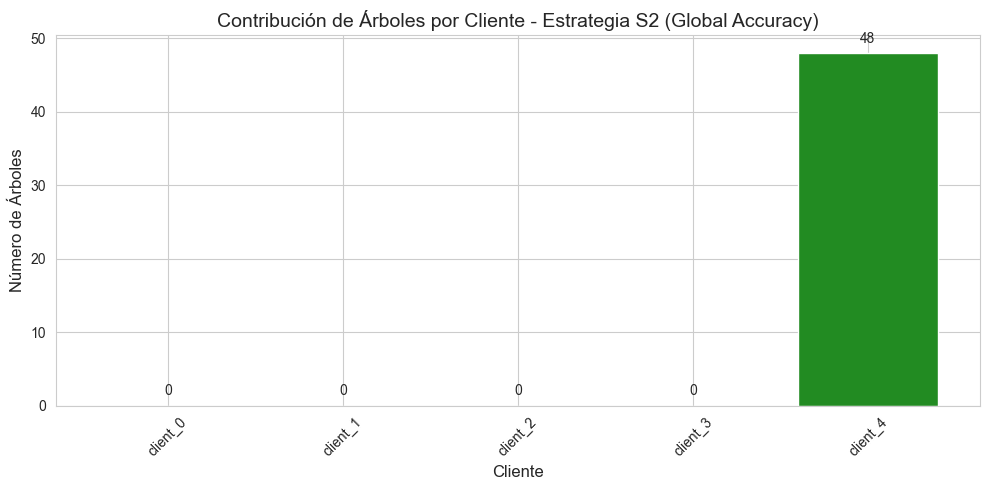

In [10]:
# Visualizar contribución de árboles por cliente
client_contributions = {cid: len(indices) for cid, indices in results.selected_ids.items()}

plt.figure(figsize=(10, 5))
bars = plt.bar(client_contributions.keys(), client_contributions.values(), color='forestgreen')
plt.xlabel('Cliente', fontsize=12)
plt.ylabel('Número de Árboles', fontsize=12)
plt.title('Contribución de Árboles por Cliente - Estrategia S2 (Global Accuracy)', fontsize=14)
plt.xticks(rotation=45)

# Añadir etiquetas de valor
for bar, val in zip(bars, client_contributions.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             str(val), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [11]:
# Mostrar top 10 árboles por accuracy
if results.all_tree_entries and len(results.all_tree_entries) > 0:
    print("\n" + "=" * 60)
    print("🏆 TOP 10 ÁRBOLES POR ACCURACY")
    print("=" * 60)
    
    # Ordenar por accuracy
    sorted_entries = sorted(results.all_tree_entries, key=lambda e: e.accuracy, reverse=True)
    
    print(f"{'Rank':<6}{'Cliente':<12}{'Accuracy':<12}{'F1-Score':<12}{'PCD':<10}")
    print("-" * 52)
    for i, entry in enumerate(sorted_entries[:10], 1):
        print(f"{i:<6}{entry.client_id:<12}{entry.accuracy:<12.4f}{entry.macro_f1:<12.4f}{entry.pcd:<10.4f}")


🏆 TOP 10 ÁRBOLES POR ACCURACY
Rank  Cliente     Accuracy    F1-Score    PCD       
----------------------------------------------------
1     client_4    0.7469      0.6251      0.7209    
2     client_4    0.7469      0.6251      0.7209    
3     client_4    0.7469      0.6251      0.7209    
4     client_4    0.7469      0.6251      0.7209    
5     client_4    0.7469      0.6251      0.7209    
6     client_4    0.7469      0.6251      0.7209    
7     client_4    0.7469      0.6251      0.7209    
8     client_4    0.7469      0.6251      0.7209    
9     client_4    0.7469      0.6251      0.7209    
10    client_4    0.7469      0.6251      0.7209    


## 6️⃣ Evaluación del Modelo Global

Evaluamos el rendimiento del bosque global en el conjunto de test.

In [12]:
print("=" * 60)
print("📊 MÉTRICAS DEL MODELO GLOBAL")
print("=" * 60)

print(f"\n🎯 Precisión (Accuracy): {results.global_accuracy:.4f}")
print(f"📊 F1-Score Macro: {results.global_macro_f1:.4f}")

# Obtener predicciones del reporte global
global_report = results.global_report
print(f"\n📈 Matriz de confusión:")
print(global_report.confusion_matrix)

📊 MÉTRICAS DEL MODELO GLOBAL

🎯 Precisión (Accuracy): 0.7435
📊 F1-Score Macro: 0.6199

📈 Matriz de confusión:
[[213  21  50]
 [ 60  29  70]
 [ 11  15 416]]


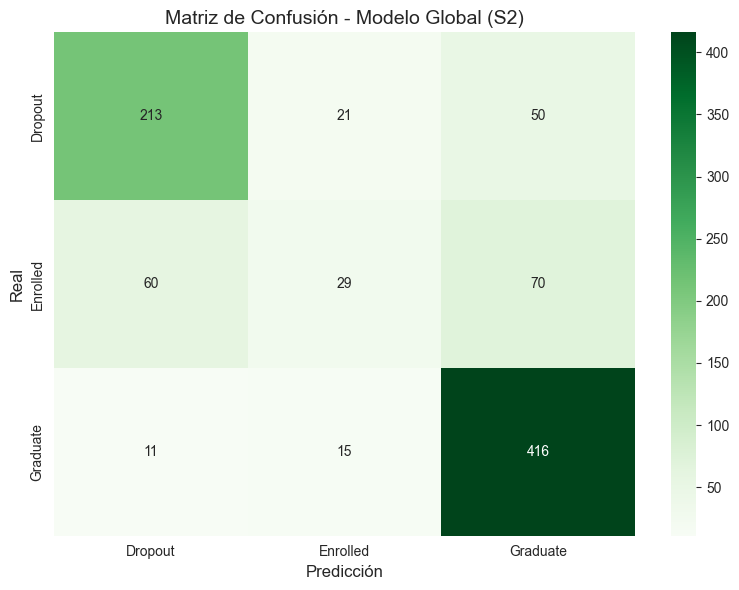

In [13]:
# Visualizar matriz de confusión
plt.figure(figsize=(8, 6))
cm = global_report.confusion_matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicción', fontsize=12)
plt.ylabel('Real', fontsize=12)
plt.title('Matriz de Confusión - Modelo Global (S2)', fontsize=14)
plt.tight_layout()
plt.show()

In [14]:
# Reporte de clasificación detallado

print("\n" + "=" * 60)
print("📋 REPORTE DE CLASIFICACIÓN")
print("=" * 60)
print(f"Accuracy: {global_report.accuracy:.4f}")
print(f"F1-Score (Macro): {global_report.macro_f1:.4f}")
print(f"Precisión (Macro): {global_report.macro_precision:.4f}")
print(f"Recall (Macro): {global_report.macro_recall:.4f}")
print(f"\nF1-Score por clase:")
for cls, f1 in global_report.per_class_f1.items():
    print(f"   {cls}: {f1:.4f}")
print(f"\nPrecisión por clase:")
for cls, prec in global_report.per_class_prec.items():
    print(f"   {cls}: {prec:.4f}")
print(f"\nRecall por clase:")
for cls, rec in global_report.per_class_recall.items():
    print(f"   {cls}: {rec:.4f}")


📋 REPORTE DE CLASIFICACIÓN
Accuracy: 0.7435
F1-Score (Macro): 0.6199
Precisión (Macro): 0.6574
Recall (Macro): 0.6245

F1-Score por clase:
   Dropout: 0.7500
   Enrolled: 0.2589
   Graduate: 0.8507

Precisión por clase:
   Dropout: 0.7500
   Enrolled: 0.4462
   Graduate: 0.7761

Recall por clase:
   Dropout: 0.7500
   Enrolled: 0.1824
   Graduate: 0.9412


## 7️⃣ Predicción Híbrida por Cliente

Cada cliente utiliza una combinación de su bosque local y el bosque global (excluyendo sus propios árboles) para realizar predicciones.

In [15]:
print("=" * 60)
print("📊 MÉTRICAS DE PREDICCIÓN HÍBRIDA POR CLIENTE")
print("=" * 60)

for client_id in results.client_ids:
    print(f"\n{client_id}:")
    print(f"   - Accuracy local: {results.client_accuracies[client_id]:.4f}")
    print(f"   - F1-Score local: {results.client_f1_scores[client_id]:.4f}")
    print(f"   - Tamaño del bosque híbrido: {results.client_hybrid_forest_sizes[client_id]} árboles")

📊 MÉTRICAS DE PREDICCIÓN HÍBRIDA POR CLIENTE

client_0:
   - Accuracy local: 0.7367
   - F1-Score local: 0.6351
   - Tamaño del bosque híbrido: 75 árboles

client_1:
   - Accuracy local: 0.7322
   - F1-Score local: 0.6077
   - Tamaño del bosque híbrido: 83 árboles

client_2:
   - Accuracy local: 0.7345
   - F1-Score local: 0.6677
   - Tamaño del bosque híbrido: 72 árboles

client_3:
   - Accuracy local: 0.7379
   - F1-Score local: 0.6652
   - Tamaño del bosque híbrido: 64 árboles

client_4:
   - Accuracy local: 0.7469
   - F1-Score local: 0.6251
   - Tamaño del bosque híbrido: 60 árboles


In [16]:
# Calcular métricas de predicción híbrida por cliente
print("\n" + "=" * 60)
print("📈 PRECISIÓN POR CLIENTE (Predicción Híbrida)")
print("=" * 60)

client_accuracies = {}
client_f1_scores = {}

for client_id, hybrid_preds in results.client_hybrid_predictions.items():
    acc = accuracy_score(results.y_test, hybrid_preds)
    f1 = f1_score(results.y_test, hybrid_preds, average='macro', zero_division=0)
    client_accuracies[client_id] = acc
    client_f1_scores[client_id] = f1
    print(f"{client_id}: Accuracy = {acc:.4f}, F1-Score = {f1:.4f}")


📈 PRECISIÓN POR CLIENTE (Predicción Híbrida)
client_0: Accuracy = 0.7503, F1-Score = 0.6191
client_1: Accuracy = 0.7412, F1-Score = 0.6007
client_2: Accuracy = 0.7537, F1-Score = 0.6548
client_3: Accuracy = 0.7582, F1-Score = 0.6463
client_4: Accuracy = 0.7446, F1-Score = 0.6236


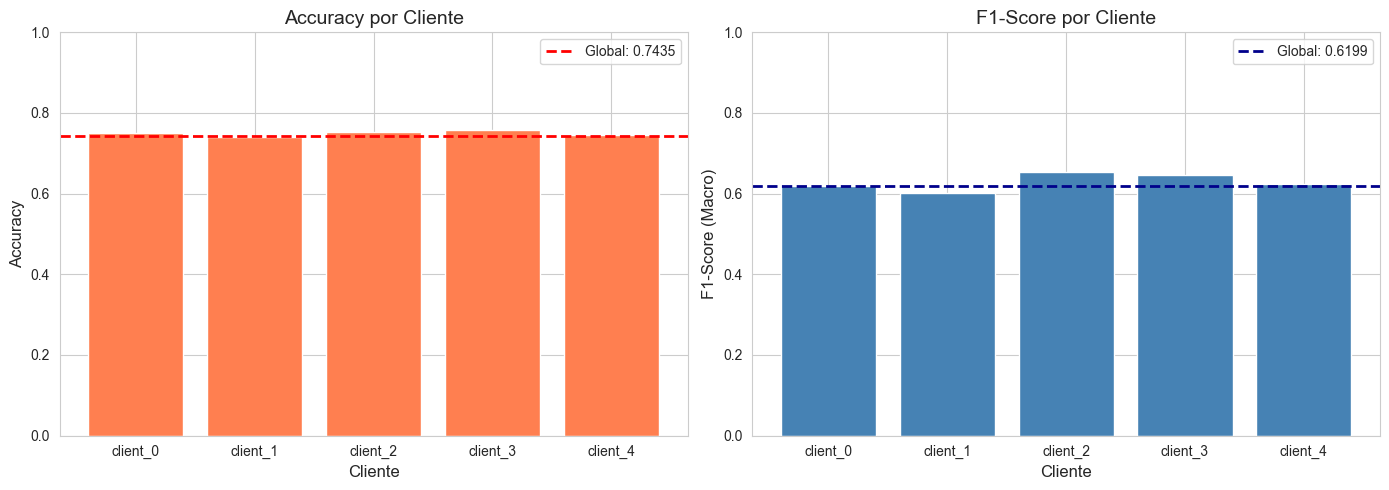

In [17]:
# Visualizar métricas por cliente
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy por cliente
ax1 = axes[0]
bars1 = ax1.bar(client_accuracies.keys(), client_accuracies.values(), color='coral')
ax1.axhline(y=results.global_accuracy, color='red', linestyle='--', linewidth=2, 
            label=f'Global: {results.global_accuracy:.4f}')
ax1.set_xlabel('Cliente', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Accuracy por Cliente', fontsize=14)
ax1.legend()
ax1.set_ylim(0, 1)

# F1-Score por cliente
ax2 = axes[1]
bars2 = ax2.bar(client_f1_scores.keys(), client_f1_scores.values(), color='steelblue')
ax2.axhline(y=results.global_macro_f1, color='darkblue', linestyle='--', linewidth=2,
            label=f'Global: {results.global_macro_f1:.4f}')
ax2.set_xlabel('Cliente', fontsize=12)
ax2.set_ylabel('F1-Score (Macro)', fontsize=12)
ax2.set_title('F1-Score por Cliente', fontsize=14)
ax2.legend()
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 📊 Resumen Final

Comparativa completa de todos los resultados.

In [18]:
# Crear resumen completo
summary_df = pd.DataFrame({
    'Cliente': list(client_accuracies.keys()),
    'Accuracy Local': [results.client_accuracies[cid] for cid in client_accuracies.keys()],
    'F1 Local': [results.client_f1_scores[cid] for cid in client_f1_scores.keys()],
    'Accuracy Híbrido': list(client_accuracies.values()),
    'F1 Híbrido': list(client_f1_scores.values()),
    'Tamaño Bosque': [results.client_hybrid_forest_sizes[cid] for cid in client_accuracies.keys()]
})

# Añadir fila global
summary_df.loc[len(summary_df)] = ['GLOBAL', results.global_accuracy, results.global_macro_f1, 
                                    results.global_accuracy, results.global_macro_f1, 
                                    results.n_trees_global]

print("\n" + "=" * 80)
print("📋 RESUMEN COMPLETO - ESTRATEGIA S2 GLOBAL ACCURACY")
print("=" * 80)
print(summary_df.to_string(index=False))


📋 RESUMEN COMPLETO - ESTRATEGIA S2 GLOBAL ACCURACY
 Cliente  Accuracy Local  F1 Local  Accuracy Híbrido  F1 Híbrido  Tamaño Bosque
client_0        0.736723  0.635109          0.750282    0.619122             75
client_1        0.732203  0.607718          0.741243    0.600744             83
client_2        0.734463  0.667728          0.753672    0.654807             72
client_3        0.737853  0.665166          0.758192    0.646341             64
client_4        0.746893  0.625091          0.744633    0.623616             60
  GLOBAL        0.743503  0.619881          0.743503    0.619881             48


C:\Users\Adrián Rodríguez\AppData\Local\Temp\ipykernel_13472\454766409.py:53: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
C:\Users\Adrián Rodríguez\AppData\Local\Temp\ipykernel_13472\454766409.py:53: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from current font.
  plt.tight_layout()
C:\Users\Adrián Rodríguez\AppData\Local\Temp\ipykernel_13472\454766409.py:53: UserWarning: Glyph 127795 (\N{DECIDUOUS TREE}) missing from current font.
  plt.tight_layout()
C:\Users\Adrián Rodríguez\AppData\Local\Temp\ipykernel_13472\454766409.py:53: UserWarning: Glyph 128101 (\N{BUSTS IN SILHOUETTE}) missing from current font.
  plt.tight_layout()
C:\Users\Adrián Rodríguez\AppData\Roaming\Python\Python38\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Adrián Rodríguez\AppData\Roaming\Python\Python38\site-packages\IPython\core\pylabtools.p

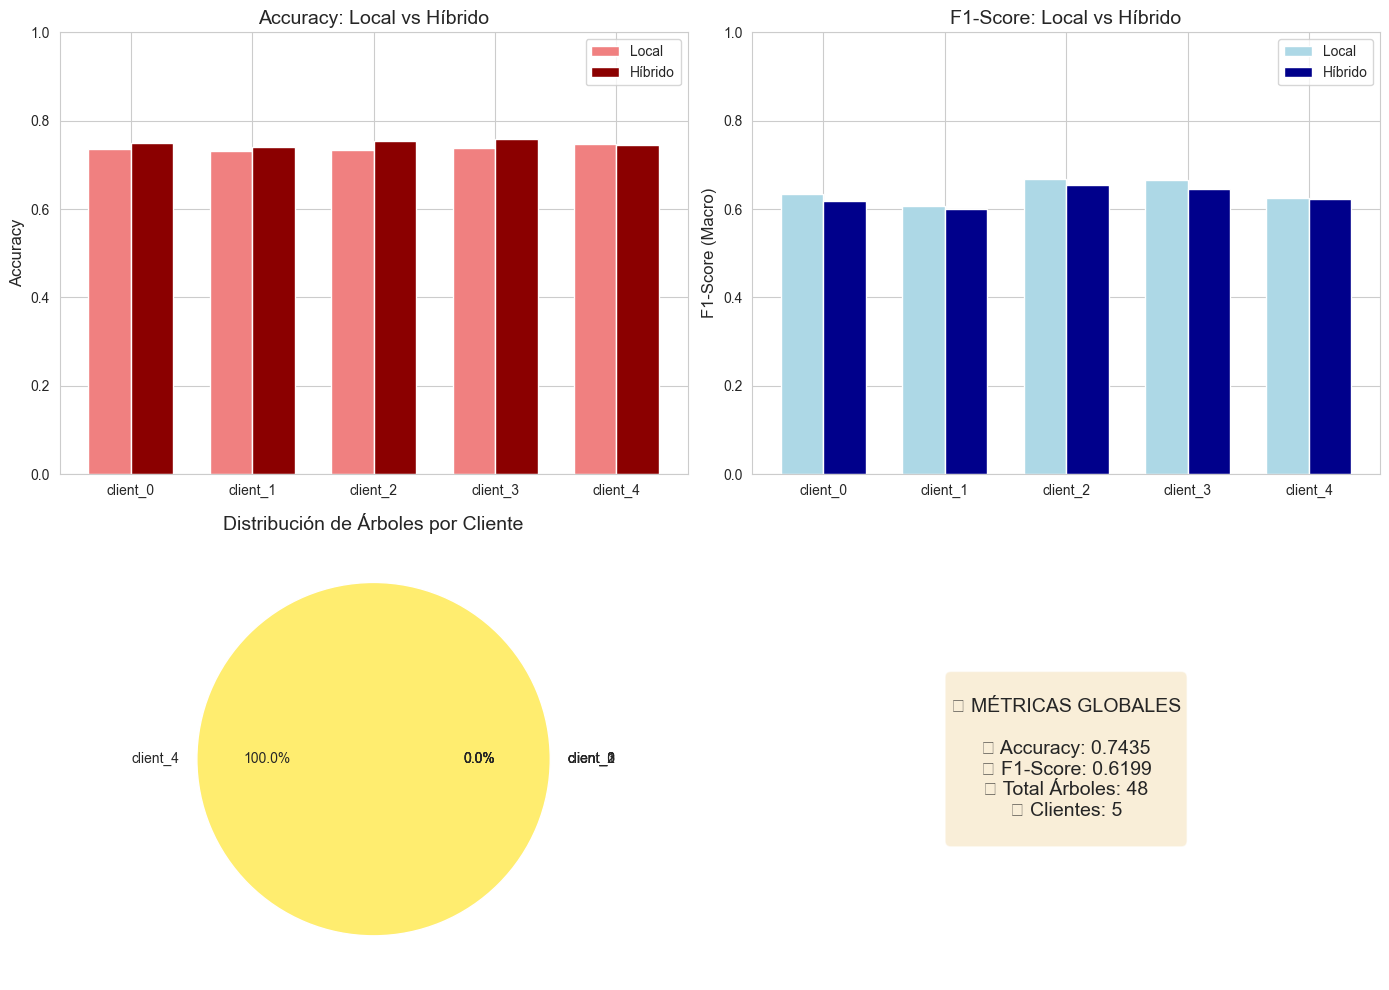

In [19]:
# Visualización comparativa final
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Comparativa Accuracy Local vs Híbrido
ax1 = axes[0, 0]
x = np.arange(len(client_accuracies))
width = 0.35
local_acc = [results.client_accuracies[cid] for cid in client_accuracies.keys()]
hybrid_acc = list(client_accuracies.values())
ax1.bar(x - width/2, local_acc, width, label='Local', color='lightcoral')
ax1.bar(x + width/2, hybrid_acc, width, label='Híbrido', color='darkred')
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Accuracy: Local vs Híbrido', fontsize=14)
ax1.set_xticks(x)
ax1.set_xticklabels(client_accuracies.keys())
ax1.legend()
ax1.set_ylim(0, 1)

# 2. Comparativa F1-Score Local vs Híbrido
ax2 = axes[0, 1]
local_f1 = [results.client_f1_scores[cid] for cid in client_f1_scores.keys()]
hybrid_f1 = list(client_f1_scores.values())
ax2.bar(x - width/2, local_f1, width, label='Local', color='lightblue')
ax2.bar(x + width/2, hybrid_f1, width, label='Híbrido', color='darkblue')
ax2.set_ylabel('F1-Score (Macro)', fontsize=12)
ax2.set_title('F1-Score: Local vs Híbrido', fontsize=14)
ax2.set_xticks(x)
ax2.set_xticklabels(client_accuracies.keys())
ax2.legend()
ax2.set_ylim(0, 1)

# 3. Distribución de árboles
ax3 = axes[1, 0]
colors = plt.cm.Set3(np.linspace(0, 1, len(results.selected_ids)))
ax3.pie([len(results.selected_ids[cid]) for cid in results.selected_ids.keys()],
        labels=results.selected_ids.keys(), autopct='%1.1f%%', colors=colors)
ax3.set_title('Distribución de Árboles por Cliente', fontsize=14)

# 4. Métricas globales
ax4 = axes[1, 1]
ax4.axis('off')
metrics_text = f"""
📊 MÉTRICAS GLOBALES

🎯 Accuracy: {results.global_accuracy:.4f}
📊 F1-Score: {results.global_macro_f1:.4f}
🌳 Total Árboles: {results.n_trees_global}
👥 Clientes: {len(results.client_ids)}
"""
ax4.text(0.5, 0.5, metrics_text, fontsize=14, ha='center', va='center',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

## ✅ Conclusiones

La estrategia **S2: Global Accuracy** utiliza un enfoque de ranking global:

1. **Ranking global**: Todos los árboles de todos los clientes se ranking por accuracy
2. **Incorporación progresiva**: Los árboles se incorporan gradualmente al bosque global
3. **Early stopping**: Progressive Forest detiene la agregación cuando converge (2 episodios consecutivos con delta < 0.002)
4. **Optimización de accuracy**: Prioriza árboles con mayor accuracy individual

**Ventajas:**
- Selecciona automáticamente los mejores árboles
- Reduce el tamaño del bosque global mediante early stopping
- Optimiza directamente la accuracy del modelo

**Desventajas:**
- Requiere datos de validación para el early stopping
- Puede favorecer árboles individuales sobre diversidad
- El accuracy individual no garantiza buena contribución al ensemble